# Pigeon PCA Tutorial

**A step-by-step guide to analysing pigeon wing morphology with `morphing_birds` and `kinematic_morphospace`**

This notebook walks you through the full workflow:

1. Loading pigeon data into the new `Animal3D` class
2. Understanding what you've loaded (markers, body sections, etc.)
3. Bilateral vs. unilateral PCA — what they are and when to use each
4. Excluding and re-including markers for different analyses
5. Running PCA with `kinematic_morphospace`
6. Reconstructing and visualising shapes from PCA scores
7. How this all differs from the old `Pigeon3D` notebook workflow

**Prerequisites:** You need `morphing_birds`, `kinematic_morphospace`, `numpy`, `pandas`, and `plotly` installed. If you're using the project environment, these should already be available.

> **Tip:** If you're new to Python, don't worry! Each step is explained in plain language before the code. When you see something unfamiliar, there's usually a comment or explanation nearby.

## Setting up

This tutorial uses two packages, both installed from GitHub:

- **`morphing_birds`** — the 3D animal skeleton library (this repo)
- **`kinematic_morphospace`** — PCA and morphospace tools built on top of it

Both are pre-configured in `examples/pyproject.toml`. From a terminal:

```bash
git clone https://github.com/LydiaFrance/morphing_birds.git
cd morphing_birds/examples
uv sync
```

This creates a `.venv` inside `examples/` with everything you need.

### Running the notebook in VS Code

1. Open the `morphing_birds` folder in VS Code (`File -> Open Folder...`).
2. Open this notebook (`examples/tutorial_pigeon_pca.ipynb`).
3. Click **Select Kernel** in the top-right of the notebook → **Python Environments...** → pick the one at `examples/.venv/bin/python` (it will be labelled something like *morphing-birds-tutorials (.venv)*).
4. If you don't see it, make sure you have the **Python** and **Jupyter** extensions installed, then reload the window (`Cmd+Shift+P` → `Developer: Reload Window`) and try again.

### Running in a browser instead (optional)

If you'd rather use JupyterLab in a browser:
```bash
uv run jupyter lab
```

> **New to `uv`?** It's a fast Python package manager. Install it with `brew install uv` (Mac) or see <https://docs.astral.sh/uv/> for other platforms.

---


## 1. Loading pigeon data

### What is `Animal3D`?

`Animal3D` is the main class (think of it as a "template" or "blueprint") in the `morphing_birds` package. It represents a 3D animal — in our case, a pigeon. You create one by telling it:

- **What species** it is (e.g. `'pigeon'`) — this loads the right skeleton configuration
- **What shape data** to start with — usually a CSV file containing the mean (average) pigeon shape

A **class** in Python is like a recipe. When you write `Animal3D('pigeon', data=...)`, you're creating a specific **object** (an instance) from that recipe. The object holds your data and gives you useful tools (called **methods**) to work with it.

Let's start by importing what we need and creating our pigeon object.

In [ ]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
import pandas as pd

from morphing_birds import (
    Animal3D, plot_plotly,
    animate_plotly, animate_plotly_compare, animate_mode
)
from kinematic_morphospace import run_PCA, reconstruct, plot_explained

### Create the pigeon object with its mean shape

The first argument `'pigeon'` tells `Animal3D` which species config to load. This config defines:
- What markers the pigeon has (e.g. wingtip, wrist, shoulder)
- How they're grouped into body sections (e.g. handwing, armwing, tail)
- Which markers are "display-only" (not used in analysis, like the head)
- How CSV column names map to marker names

The `data=` argument points to the CSV file containing the **mean shape** — the average pigeon posture. This becomes the "default" shape that the object starts with.

In [2]:
# Create a pigeon object, loading the mean shape from CSV
pigeon = Animal3D('pigeon', data='../data/mean_pigeon_shape.csv')

# Print it to see a summary — this uses the __repr__ method, which gives
# you a quick overview of the object's state
print(pigeon)

Animal3D('pigeon', 19 markers, no motion data loaded)


### Load the motion data

Now we load the actual flight data — many frames of pigeon shapes captured during flight. The `load_motion_data()` method reads a CSV and returns a numpy array with shape `(n_frames, n_markers, 3)`.

**What does that shape mean?**
- `n_frames` = how many time points (snapshots) were recorded
- `n_markers` = how many markers are on the pigeon (19 for the full pigeon)
- `3` = the x, y, z coordinates of each marker

A **method** is just a function that belongs to an object. You call it with `pigeon.load_motion_data(...)` — the dot means "use this method that belongs to the pigeon object".

In [3]:
# Load multi-frame motion data from CSV
# This prints a summary of what was loaded, including any warnings
motion_data = pigeon.load_motion_data('../data/FullPigeons.csv')

print(f"\nShape of motion_data: {motion_data.shape}")
print(f"  That's {motion_data.shape[0]} frames, {motion_data.shape[1]} markers, {motion_data.shape[2]} coordinates (x,y,z)")

Loaded 14243 frames with 19 markers using 'pigeon' column mapping
  This may indicate missing CSV columns or a column mapping mismatch
Note: 3 CSV columns not matched to any marker: Middle_Tail_x, Middle_Tail_y, Middle_Tail_z

Shape of motion_data: (14243, 19, 3)
  That's 14243 frames, 19 markers, 3 coordinates (x,y,z)


### Matching units between the mean shape and the motion data

For this dataset, the mean-shape CSV is stored in **metres** and the motion-capture CSV in **centimetres**. They need to be in the same units before we can combine them — otherwise the analysis markers (shoulders, wingtips) come from motion data at one scale and display-only markers (head, tailbases, body_base) stay at the mean-shape scale, and polygons that depend on both collapse.

Convert the motion data into metres to match the mean shape:


In [4]:
from morphing_birds import unit_conversion_factor

motion_data = motion_data * unit_conversion_factor('cm', 'm')
print(f"Motion data now in metres. Sample shoulder x: {motion_data[0, pigeon.skeleton.marker_index('right_shoulder'), 0]:.3f}")


Motion data now in metres. Sample shoulder x: 0.337


In [ ]:
# Print the pigeon again — now it shows the frame count
print(pigeon)

# Plot the mean pigeon shape
fig = plot_plotly(pigeon, colour='cornflowerblue')
fig.show()

Animal3D('pigeon', 19 markers, 14243 frames loaded, 14 in analysis set)


## 2. Understanding what you've loaded

Let's explore the pigeon object to understand its structure. This is useful for debugging and for knowing what data you're working with.

### Markers

Markers are the named points on the pigeon's body that were tracked during flight. Each marker has an (x, y, z) position in 3D space.

In [6]:
# All markers defined in the pigeon skeleton (in config order)
print("All markers:")
for i, name in enumerate(pigeon.skeleton.all_marker_names):
    print(f"  {i:2d}. {name}")

All markers:
   0. left_wingtip
   1. right_wingtip
   2. left_wrist
   3. right_wrist
   4. left_secondary
   5. right_secondary
   6. left_lastsecondary_tip
   7. right_lastsecondary_tip
   8. left_elbow
   9. right_elbow
  10. left_shoulder
  11. right_shoulder
  12. left_tailtip
  13. right_tailtip
  14. centre_body_base
  15. head
  16. centre_backpack
  17. left_tailbase
  18. right_tailbase


### Analysis markers vs. display-only markers

Not all markers are used for analysis. Some markers (like the head and backpack) don't move in interesting ways during wing morphing, so they're **excluded** from the analysis set by default. They're still available for visualisation though — that's why they're called "display-only".

The **analysis markers** are the ones that will be used when we do PCA later.

In [7]:
# Markers used in analysis (the "moving" markers)
print("Analysis markers:")
for name in pigeon.analysis_marker_names:
    print(f"  - {name}")

print(f"\nTotal: {len(pigeon.analysis_marker_names)} analysis markers "
      f"out of {pigeon.skeleton.n_markers} total")

# Which markers are excluded?
print("\nExcluded (display-only) markers:")
for name in sorted(pigeon._analysis_exclude):
    print(f"  - {name}")

Analysis markers:
  - left_wingtip
  - right_wingtip
  - left_wrist
  - right_wrist
  - left_secondary
  - right_secondary
  - left_lastsecondary_tip
  - right_lastsecondary_tip
  - left_elbow
  - right_elbow
  - left_shoulder
  - right_shoulder
  - left_tailtip
  - right_tailtip

Total: 14 analysis markers out of 19 total

Excluded (display-only) markers:
  - centre_backpack
  - centre_body_base
  - head
  - left_tailbase
  - right_tailbase


### Column mapping

The CSV files from the motion capture system use different column names (like `Right_Tip`) than the internal marker names (like `right_wingtip`). The **column mapping** translates between them automatically.

You don't usually need to worry about this — it's handled by the pigeon config — but it's useful to see if you ever get "unmatched columns" warnings.

In [8]:
# See the column mapping: internal name -> CSV column name
print("Column mapping (internal name -> CSV column name):")
for internal, csv_col in pigeon.skeleton.column_mapping.items():
    print(f"  {internal:30s} -> {csv_col}")

Column mapping (internal name -> CSV column name):
  head                           -> Head
  centre_backpack                -> Body_Start
  centre_body_base               -> Body_End
  left_tailtip                   -> Left_Tail
  right_tailtip                  -> Right_Tail
  right_lastsecondary_tip        -> Right_Shoulder_Trailing_Edge
  right_elbow                    -> Right_Shoulder_End
  right_shoulder                 -> Right_Shoulder_Start
  left_lastsecondary_tip         -> Left_Shoulder_Trailing_Edge
  left_elbow                     -> Left_Shoulder_End
  left_shoulder                  -> Left_Shoulder_Start
  right_wingtip                  -> Right_Tip
  right_wrist                    -> Right_Wrist_Leading_Edge
  right_secondary                -> Right_Wrist_Trailing_Edge
  left_wingtip                   -> Left_Tip
  left_wrist                     -> Left_Wrist_Leading_Edge
  left_secondary                 -> Left_Wrist_Trailing_Edge
  left_tailbase                  -> L

### Body sections

Body sections define how markers are grouped into polygons for plotting. Each section is a list of markers that form a shape (like a wing outline or the tail fan).

In [9]:
# Body sections — these define the polygons used for 3D plotting
print("Body sections:")
for section_name, marker_indices in pigeon.polygons.items():
    # Convert indices back to names for readability
    names = [pigeon.skeleton.all_marker_names[i] for i in marker_indices]
    print(f"  {section_name}: {names}")

Body sections:
  head: ['right_shoulder', 'head', 'left_shoulder']
  body: ['right_shoulder', 'right_tailbase', 'centre_body_base', 'left_tailbase', 'left_shoulder']
  tail: ['right_tailbase', 'centre_body_base', 'left_tailbase', 'left_tailtip', 'right_tailtip']
  right_armwing: ['right_shoulder', 'right_elbow', 'right_wrist', 'right_secondary', 'right_lastsecondary_tip', 'right_tailbase']
  left_armwing: ['left_shoulder', 'left_elbow', 'left_wrist', 'left_secondary', 'left_lastsecondary_tip', 'left_tailbase']
  left_handwing: ['left_wrist', 'left_secondary', 'left_wingtip']
  right_handwing: ['right_wrist', 'right_secondary', 'right_wingtip']


### Quick visualisation of the mean shape

Let's plot the mean pigeon shape to see what we're working with. `plot_plotly()` creates an interactive 3D plot — you can rotate and zoom it in the notebook.

In [10]:
# Plot the mean pigeon shape
fig = plot_plotly(pigeon, colour='cornflowerblue')
fig.show()

## 3. Bilateral and unilateral PCA

Before we run PCA, we need to decide: **bilateral or unilateral?**

### What's the difference?

**Bilateral PCA** uses the full bird shape — left wing, right wing, and tail — all at once. This captures how the *entire* bird changes shape, including any asymmetries between left and right sides.

**Unilateral PCA** treats each side of the bird separately. It takes the left-side markers, mirrors them to look like right-side data, and then combines both sides into one dataset with twice as many observations. This means:
- You get double the data points (which is good for statistics)
- You capture how a *single wing* changes shape
- Asymmetries are averaged out

### When to use which?

| Use case | Approach |
|---|---|
| Studying wing shape variation (most common) | **Unilateral** |
| Studying asymmetric manoeuvres (turning, banking) | **Bilateral** |
| Need more statistical power | **Unilateral** (doubles your sample size) |
| Looking at whole-body posture | **Bilateral** |

For this tutorial, we'll use **unilateral PCA** since we're interested in how the wing shape varies during flight.

## 4. Excluding and re-including markers

Before running PCA, you might want to adjust which markers are included. For example, you might want to exclude the tail markers and focus only on the wing.

The `get_analysis_data()` method slices the motion data to include only the current analysis markers (i.e. it removes the excluded ones from the data array).

In [11]:
# First, let's see what's currently in the analysis set
print("Current analysis markers:")
print(pigeon.analysis_marker_names)
print(f"Count: {len(pigeon.analysis_marker_names)}")

Current analysis markers:
['left_wingtip', 'right_wingtip', 'left_wrist', 'right_wrist', 'left_secondary', 'right_secondary', 'left_lastsecondary_tip', 'right_lastsecondary_tip', 'left_elbow', 'right_elbow', 'left_shoulder', 'right_shoulder', 'left_tailtip', 'right_tailtip']
Count: 14


In [12]:
# Let's try excluding the tail markers to focus on wings only
pigeon.exclude_markers(['left_tailtip', 'right_tailtip'])

print("After excluding tail tips:")
print(pigeon.analysis_marker_names)
print(f"Count: {len(pigeon.analysis_marker_names)}")

fig = plot_plotly(pigeon, colour='cornflowerblue')
fig.show()

After excluding tail tips:
['left_wingtip', 'right_wingtip', 'left_wrist', 'right_wrist', 'left_secondary', 'right_secondary', 'left_lastsecondary_tip', 'right_lastsecondary_tip', 'left_elbow', 'right_elbow', 'left_shoulder', 'right_shoulder']
Count: 12


In [13]:
# Now re-include them — we actually want the tail for our full analysis
pigeon.include_markers(['left_tailtip', 'right_tailtip'])

print("After re-including tail tips:")
print(pigeon.analysis_marker_names)
print(f"Count: {len(pigeon.analysis_marker_names)}")

fig = plot_plotly(pigeon, colour='cornflowerblue')
fig.show()

After re-including tail tips:
['left_wingtip', 'right_wingtip', 'left_wrist', 'right_wrist', 'left_secondary', 'right_secondary', 'left_lastsecondary_tip', 'right_lastsecondary_tip', 'left_elbow', 'right_elbow', 'left_shoulder', 'right_shoulder', 'left_tailtip', 'right_tailtip']
Count: 14


In [14]:
# get_analysis_data() slices the full motion data to only the analysis markers.
# It prints a summary telling you how many markers are included.
analysis_data = pigeon.get_analysis_data(motion_data)
print(f"Analysis data shape: {analysis_data.shape}")

Analysis data: 14 of 19 markers (excluded: centre_backpack, centre_body_base, head, left_tailbase, right_tailbase)
Analysis data shape: (14243, 14, 3)


## 5. Running PCA with kinematic_morphospace

Now we're ready for the main event! We'll:

1. **Remove NaN frames** — some frames may have missing data
2. **Convert to unilateral** — mirror the left side so we have double the data
3. **Run PCA** — using `kinematic_morphospace.run_PCA()`, which handles the flattening and centring for you

### What is PCA?

**Principal Component Analysis** finds the main patterns of variation in your data. Think of it as finding the "axes" along which the wing shape varies most. PC1 might capture wing extension/retraction, PC2 might capture wing sweep, and so on. Each PC is independent of the others.

### What is kinematic_morphospace?

`kinematic_morphospace` is a companion package that handles the PCA workflow for motion capture data. It takes care of flattening, centring, running the PCA, and reconstructing shapes — so you don't have to do those steps manually.

In [15]:
# Step 1: Remove frames with NaN (missing) values
# By default this only checks analysis markers, so occlusions on display-only
# markers (like the head or tailbase) won't throw out otherwise-good frames.
clean_data, valid_mask = pigeon.remove_nan_frames(analysis_data)
print(f"Removed {analysis_data.shape[0] - clean_data.shape[0]} NaN frames")
print(f"Remaining: {clean_data.shape[0]} frames")

Removed 9525 NaN frames
Remaining: 4718 frames


In [ ]:
# Step 2: Convert to unilateral data
# This mirrors the left side and doubles the number of observations.
# We use pigeon.make_unilateral() which automatically respects any markers
# you've excluded with exclude_markers(). It needs the FULL motion data
# (not analysis-sliced) because it needs to know which markers are left/right.
clean_full, valid_mask_full = pigeon.remove_nan_frames(motion_data)
print(f"Bilateral data:  {clean_full.shape[0]} frames x {clean_full.shape[1]} markers")

unilateral_data, is_left, _ = pigeon.make_unilateral(clean_full)

print(f"Unilateral data: {unilateral_data.shape[0]} frames x {unilateral_data.shape[1]} markers")
print(f"  (Frame count doubled because each frame contributes a left and right observation)")

In [17]:
# Step 3: Run PCA!
# run_PCA() handles the flattening and centring internally.
# It returns three things:
#   - principal_components: the loading vectors (patterns of shape change)
#   - scores: how much each frame expresses each pattern
#   - pca_object: the fitted PCA object (from scikit-learn under the hood)
principal_components, scores, pca_object = run_PCA(unilateral_data)

# How much variation does each PC explain?
print("Variance explained by each PC:")
for i, var in enumerate(pca_object.explained_variance_ratio_[:5]):
    print(f"  PC{i+1}: {var*100:.1f}%")

print(f"\nTotal explained by first 5 PCs: "
      f"{sum(pca_object.explained_variance_ratio_[:5])*100:.1f}%")

Variance explained by each PC:
  PC1: 69.7%
  PC2: 19.7%
  PC3: 6.3%
  PC4: 2.5%
  PC5: 0.6%

Total explained by first 5 PCs: 98.8%


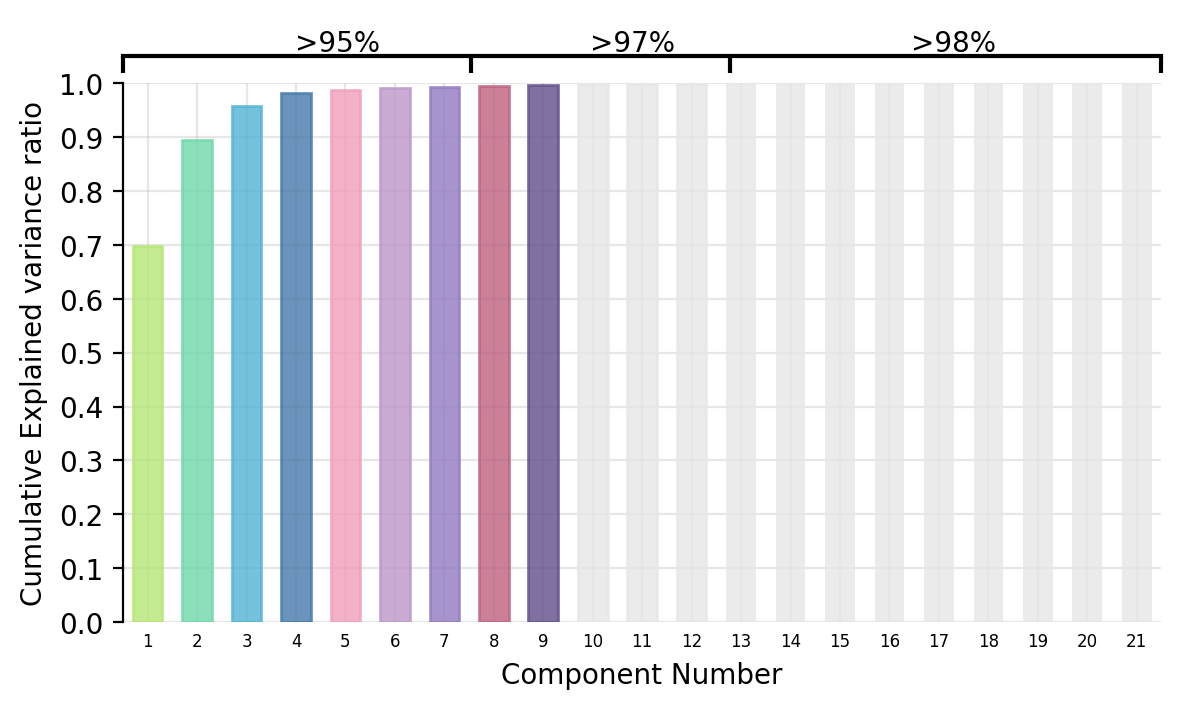

In [18]:
# Visualise the explained variance as a bar chart
# This shows how much of the total shape variation each PC captures
fig_var, ax_var = plot_explained(pca_object.explained_variance_ratio_)

## 6. Visualising PCA modes

Now for the fun part! We can animate what the pigeon looks like as each PC score varies. This lets us visualise what each principal component *means* physically.

The `animate_mode` function handles this for you. It:
- Sweeps the selected PC score from -2 to +2 standard deviations
- Reconstructs the shape at each step using the principal components and mean
- Mirrors the unilateral reconstruction back to bilateral
- Creates an interactive animation with play/pause and a slider

First, we need to compute the mean shape (which PCA centred around):

In [19]:
# Compute the mean shape — animate_mode needs this for reconstruction
n_markers = unilateral_data.shape[1]
flat_data = unilateral_data.reshape(unilateral_data.shape[0], n_markers * 3)
mu = flat_data.mean(axis=0).reshape(1, n_markers, 3)

print(f"Mean shape: {mu.shape}")
print(f"  That's (1, n_markers, 3) — the average unilateral wing shape")

Mean shape: (1, 7, 3)
  That's (1, n_markers, 3) — the average unilateral wing shape


### Animating PCA modes

The `animate_mode` function makes it easy to visualise what each principal component represents. It sweeps the PC score from -2 to +2 standard deviations (and back), reconstructing and animating the shape at each step. This creates a looping animation that shows the full range of shape variation captured by that PC.

`animate_mode` handles all the complexity internally:
- Reconstructing shapes from scores
- Mirroring unilateral data back to bilateral
- Creating the Plotly animation with play/pause controls and a slider

In [20]:
# Define a colour for each PC (used by animate_mode)
pc_colours = ['tomato', 'steelblue', 'mediumseagreen', 'gold', 'purple']

# Animate PC1 — sweeps from -2 to +2 standard deviations and back
# The slider shows the PC score at each frame
fig = animate_mode(1, pigeon, principal_components, scores, mu, pc_colours)

In [21]:
# Animate PC2
fig = animate_mode(2, pigeon, principal_components, scores, mu, pc_colours)

In [22]:
# Animate PC3
fig = animate_mode(3, pigeon, principal_components, scores, mu, pc_colours)

### Animating real flight data

You can also animate actual recorded flight data to see how the pigeon moved during the capture session. We use `animate_plotly` with a subset of the cleaned frames.

**Important:** `animate_plotly` expects analysis markers only (14 for the pigeon), not all 19 markers. Use `get_analysis_data()` to extract just the analysis markers before animating.

In [23]:
# Animate a short segment of real flight data
# animate_plotly expects analysis markers only (14), not all markers (19),
# so we use get_analysis_data to extract just the analysis markers.
analysis_clean = pigeon.get_analysis_data(clean_full)
fig = animate_plotly(pigeon, analysis_clean[0:100], colour='mediumseagreen')
fig.show()

Analysis data: 14 of 19 markers (excluded: centre_backpack, centre_body_base, head, left_tailbase, right_tailbase)


### Comparing original vs PCA reconstruction

How much information do the first few PCs actually capture? We can visualise this by comparing the original flight data with a reconstruction that uses only 4 PCs.

The reconstruction projects each frame onto the 4-PC subspace and back — any shape variation outside those 4 dimensions is lost. If 4 PCs capture most of the variance, the two shapes should look nearly identical.

In [ ]:
# Reconstruct flight data using only the first 4 PCs
#
# The key is to reconstruct ALL unilateral scores (both left and right halves),
# then use make_bilateral with the original is_left mask. This preserves asymmetry
# because each side gets its own reconstruction.

n_pcs = 4

# Reconstruct all unilateral scores with 4 PCs
recon_unilateral = reconstruct(scores, principal_components, mu, 
                                components_list=list(range(n_pcs)))

# Recombine into bilateral using the original is_left mask from make_unilateral
# This preserves asymmetry - left and right sides have different scores
recon_bilateral_full = pigeon.make_bilateral(recon_unilateral, is_left)

# Extract analysis markers only (to match analysis_clean which has 14, not 19)
recon_bilateral = pigeon.get_analysis_data(recon_bilateral_full)

print(f"Original bilateral data: {analysis_clean.shape}")
print(f"{n_pcs}-PC reconstruction: {recon_bilateral.shape}")
print(f"Variance captured by {n_pcs} PCs: {sum(pca_object.explained_variance_ratio_[:n_pcs])*100:.1f}%")

# Compare first 100 frames: original (blue) vs 4-PC reconstruction (red)
fig = animate_plotly_compare(
    pigeon,
    [analysis_clean[0:100], recon_bilateral[0:100]],
    colours=['cornflowerblue', 'tomato']
)
fig.update_layout(title=f"Original (blue) vs {n_pcs}-PC reconstruction (red)")
fig.show()

## 7. How this differs from the old notebook workflow

If you've been using Lydia's older notebooks, you'll have seen a class called `Pigeon3D`. That class has been replaced by the unified `Animal3D` class in v0.2.0. Here's a quick comparison:

### Creating the object

**Old way (v0.1):**
```python
from morphing_birds import Pigeon3D

pigeon = Pigeon3D(MeanPigeonData)
```

**New way (v0.2.0):**
```python
from morphing_birds import Animal3D

pigeon = Animal3D('pigeon', data='../data/mean_pigeon_shape.csv')
```

The key difference: instead of separate classes for each species (`Pigeon3D`, `Hawk3D`, `Kestrel3D`), there's now one `Animal3D` class that takes the species name as its first argument. The species name loads the right configuration automatically.

### Loading motion data

**Old way:**
```python
# Had to manually read the CSV, align columns, reshape...
df = pd.read_csv('FullPigeons.csv')
# ...lots of manual column matching code...
```

**New way:**
```python
motion_data = pigeon.load_motion_data('../data/FullPigeons.csv')
# That's it! Column mapping is handled automatically.
```

### Excluding markers

**Old way:**
```python
# Had to manually remove columns from the data array
# and keep track of which indices corresponded to which markers
```

**New way:**
```python
pigeon.exclude_markers(['left_tailtip', 'right_tailtip'])
analysis_data = pigeon.get_analysis_data(motion_data)
# Clean and explicit
```

### Bilateral/unilateral conversion

**Old way:**
```python
# Custom functions buried in notebook cells
```

**New way:**
```python
# Use the Animal3D methods — they automatically respect exclude_markers()
unilateral, is_left, _ = pigeon.make_unilateral(motion_data)
bilateral = pigeon.make_bilateral(unilateral, is_left)
```

### Plotting

**Old way:**
```python
pigeon.plot()  # matplotlib only
```

**New way:**
```python
from morphing_birds import plot_plotly
fig = plot_plotly(pigeon)  # interactive 3D plot
```

### Summary of benefits

- **One class for all species** — no need to learn different APIs for pigeons vs. hawks
- **Automatic column mapping** — no more manual CSV column wrangling
- **Built-in data loading** — `load_motion_data()` handles everything
- **Clear marker management** — `exclude_markers()` / `include_markers()` with named markers
- **Consistent bilateral conversion** — `make_unilateral()` / `make_bilateral()` methods respect your marker exclusions
- **Better printing** — `print(pigeon)` tells you what state the object is in
- **Interactive plots** — Plotly support built in